# Merge & Compare — Multi-machine Results

Gộp kết quả từ nhiều thư mục `output_<timestamp>` để so sánh cấu hình.

In [11]:
import json
import os
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

# ════════════════════════════════════════════════════════════════
# Scan tất cả output directories có logs.json hợp lệ
# ════════════════════════════════════════════════════════════════
OUTPUTS_DIR = Path("artifacts/outputs")

all_runs = []
for run_dir in sorted(OUTPUTS_DIR.glob("output_*")):
    logs_path = run_dir / "logs.json"
    if not logs_path.exists():
        continue
    with open(logs_path, encoding="utf-8") as f:
        data = json.load(f)
    if "result" not in data:
        continue
    all_runs.append(data)

print(f"Found {len(all_runs)} valid runs with test results.")

# ════════════════════════════════════════════════════════════════
# Generate experiment name from actual param values (abbreviated)
# ════════════════════════════════════════════════════════════════
TRACKED_PARAMS = {
    "agent.gamma": lambda d: d["parameters"]["agent"]["gamma"],
    "agent.lr": lambda d: d["parameters"]["agent"]["lr"],
    "agent.lr_decay": lambda d: d["parameters"]["agent"]["lr_decay"],
    "agent.tau": lambda d: d["parameters"]["agent"]["tau"],
    "agent.eps_decay": lambda d: d["parameters"]["agent"]["eps_decay"],
    "agent.batch_size": lambda d: d["parameters"]["agent"]["batch_size"],
    "agent.buffer_cap": lambda d: d["parameters"]["agent"]["buffer_cap"],
    "training.learn_every": lambda d: d["parameters"]["training"]["learn_every"],
}

# Abbreviated keys for compact naming
PARAM_ABBREV = {
    "agent.gamma": "g",
    "agent.lr": "lr",
    "agent.lr_decay": "lrd",
    "agent.tau": "tau",
    "agent.eps_decay": "ed",
    "agent.batch_size": "bs",
    "agent.buffer_cap": "buf",
    "training.learn_every": "le",
}

def format_param_value(val):
    """Format a param value for use in experiment name."""
    if isinstance(val, float):
        # Use scientific notation for very small values
        if val < 0.001:
            return f"{val:.0e}".replace("e-0", "e-").replace("e+0", "e")
        # Remove leading 0 and trailing zeros for decimals
        s = f"{val:g}"
        return s
    if isinstance(val, int):
        if val >= 10000:
            return f"{val // 1000}k"
        return str(val)
    return str(val)

def get_param_signature(run_data):
    sig = {}
    for key, extractor in TRACKED_PARAMS.items():
        try:
            sig[key] = extractor(run_data)
        except (KeyError, TypeError):
            sig[key] = None
    return sig

def make_experiment_name(sig):
    """Build experiment name from all param values."""
    parts = []
    for key in TRACKED_PARAMS:
        val = sig.get(key)
        if val is None:
            continue
        abbrev = PARAM_ABBREV[key]
        parts.append(f"{abbrev}{format_param_value(val)}")
    return "_".join(parts)

# ════════════════════════════════════════════════════════════════
# Build merged results
# ════════════════════════════════════════════════════════════════
merged_results = []

for run in all_runs:
    sig = get_param_signature(run)
    name = make_experiment_name(sig)
    avg = run["result"].get("test_metrics", {}).get("average", {})
    merged_results.append({
        "Experiment": name,
        "Return%": avg.get("return_pct", 0),
        "Sharpe": avg.get("sharpe", 0),
        "WinRate%": avg.get("win_rate", 0),
        "MaxDD%": avg.get("max_dd_pct", 0),
        "N_trades": avg.get("n_trades", 0),
        "PF": avg.get("profit_factor", 0),
        "Score": run["result"]["best_score"],
        "Time(min)": run.get("elapsed_minutes", 0),
        "run_dir": str(OUTPUTS_DIR / run["run_id"]),
        "run_id": run["run_id"],
    })

# ════════════════════════════════════════════════════════════════
# Dedup: keep only the run with highest WinRate% per config
# ════════════════════════════════════════════════════════════════
df_all = pd.DataFrame(merged_results)
df_all = df_all.sort_values("WinRate%", ascending=False).drop_duplicates(subset="Experiment", keep="first")
merged_results = df_all.to_dict("records")

print(f"Detected {len(merged_results)} unique configs (deduped by best WinRate%)")

Found 34 valid runs with test results.
Detected 15 unique configs (deduped by best WinRate%)


In [12]:
# ════════════════════════════════════════════════════════════════
# Summary DataFrame — sort by Sharpe
# ════════════════════════════════════════════════════════════════
df_merged = pd.DataFrame(merged_results)
df_merged = df_merged.sort_values("Sharpe", ascending=False).reset_index(drop=True)

# Export CSV
os.makedirs("artifacts/outputs", exist_ok=True)
df_merged.to_csv("artifacts/outputs/all_configs_comparison.csv", index=False)

# Styled display with conditional coloring
display_cols = ["Experiment", "Return%", "Sharpe", "WinRate%", "MaxDD%", "PF", "Score", "run_dir"]
styled = df_merged[display_cols].style.background_gradient(
    subset=["Sharpe", "Return%", "WinRate%", "PF"], cmap="RdYlGn"
).background_gradient(
    subset=["MaxDD%"], cmap="RdYlGn_r"
).format({
    "Return%": "{:+.2f}",
    "Sharpe": "{:+.4f}",
    "WinRate%": "{:.1f}",
    "MaxDD%": "{:.2f}",
    "PF": "{:.2f}",
    "Score": "{:.4f}",
})
display(styled)

# ⭐ Best Config
best = df_merged.iloc[0]
best_run = next(r for r in all_runs if r["run_id"] == best["run_id"])
print(f"\n{'═'*60}")
print(f"⭐ BEST CONFIG: {best['Experiment']}")
print(f"{'═'*60}")
print(f"   Run dir : {best['run_dir']}")
print(f"   Weights : {best['run_dir']}/weights/best_model.pkl")
print(f"   Sharpe={best['Sharpe']:+.4f} | Return={best['Return%']:+.2f}% | WR={best['WinRate%']:.1f}% | PF={best['PF']:.2f}")
print(f"\n   Per-stock:")
for stock, m in best_run["result"]["test_metrics"].items():
    if stock == "average": continue
    print(f"     {stock}: Ret={m['return_pct']:+.2f}% Sharpe={m['sharpe']:+.4f} WR={m['win_rate']:.1f}%")
print(f"\n💾 Saved → artifacts/outputs/all_configs_comparison.csv")

,Experiment,Return%,Sharpe,WinRate%,MaxDD%,PF,Score,run_dir
0,g0.97_lr5e-4_lrd0.995_tau0.01_ed0.997_bs256_buf20k_le4,+6.03,+0.6008,59.7,-5.40,2.17,0.3456,artifacts\outputs\output_20260529_013135
1,g0.97_lr5e-4_lrd0.995_tau0.005_ed0.997_bs256_buf20k_le4,+2.73,+0.4937,70.2,-5.01,14329250001.07,0.3758,artifacts\outputs\output_20260528_231129
2,g0.97_lr5e-4_lrd0.995_tau0.005_ed0.997_bs256_buf20k_le2,+1.99,+0.3942,65.3,-5.30,8126500001.28,0.3679,artifacts\outputs\output_20260529_003822
3,g0.97_lr5e-4_lrd0.995_tau0.005_ed0.999_bs256_buf20k_le4,+3.13,+0.2262,59.9,-6.39,6.90,0.4455,artifacts\outputs\output_20260529_045129
4,g0.99_lr5e-4_lrd0.995_tau0.005_ed0.997_bs256_buf20k_le4,+2.49,+0.2082,61.2,-8.27,2.72,0.3730,artifacts\outputs\output_20260528_235925
5,g0.97_lr5e-4_lrd0.995_tau0.005_ed0.997_bs128_buf50k_le4,+1.14,-0.0835,61.3,-6.76,1.69,0.4632,artifacts\outputs\output_20260528_225105
6,g0.9_lr5e-4_lrd0.995_tau0.005_ed0.997_bs256_buf20k_le4,+1.48,-0.1797,56.1,-8.26,1.64,0.4398,artifacts\outputs\output_20260528_221742
7,g0.97_lr5e-4_lrd0.995_tau0.005_ed0.997_bs256_buf20k_le8,+0.46,-0.2226,68.5,-4.68,1799250001.40,0.4395,artifacts\outputs\output_20260529_024548
8,g0.97_lr5e-4_lrd0.995_tau0.005_ed0.995_bs256_buf20k_le4,-0.77,-0.3452,54.1,-8.04,1.62,0.3710,artifacts\outputs\output_20260529_031725
9,g0.97_lr0.001_lrd0.998_tau0.005_ed0.997_bs256_buf20k_le4,-1.74,-0.6399,65.0,-11.01,3.66,0.3728,artifacts\outputs\output_20260528_234158



════════════════════════════════════════════════════════════
⭐ BEST CONFIG: g0.97_lr5e-4_lrd0.995_tau0.01_ed0.997_bs256_buf20k_le4
════════════════════════════════════════════════════════════
   Run dir : artifacts\outputs\output_20260529_013135
   Weights : artifacts\outputs\output_20260529_013135/weights/best_model.pkl
   Sharpe=+0.6008 | Return=+6.03% | WR=59.7% | PF=2.17

   Per-stock:
     VNM: Ret=-2.03% Sharpe=-0.7437 WR=54.5%
     FPT: Ret=-6.05% Sharpe=-1.6900 WR=38.9%
     VIC: Ret=+25.95% Sharpe=+4.0000 WR=78.6%
     HPG: Ret=+6.24% Sharpe=+0.8369 WR=66.7%

💾 Saved → artifacts/outputs/all_configs_comparison.csv


## 1. Heatmap Overview

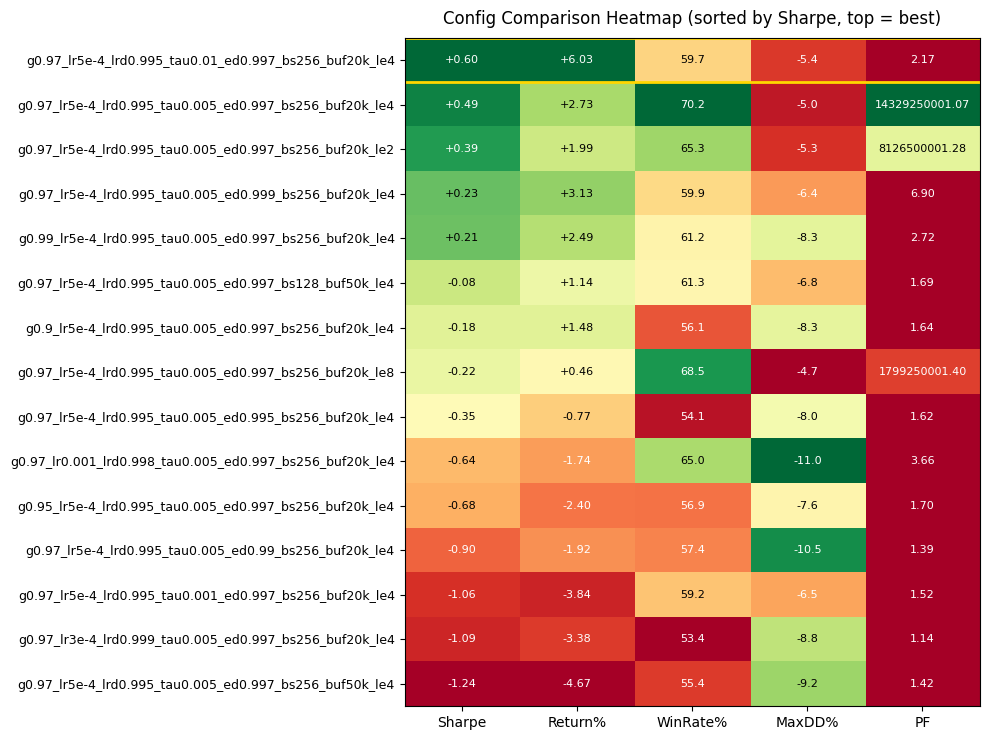

💾 Saved → artifacts/outputs/heatmap_overview.png


In [13]:
# ════════════════════════════════════════════════════════════════
# Heatmap: compact overview of all configs × metrics
# Rows = experiments (sorted by Sharpe), Cols = metrics
# ════════════════════════════════════════════════════════════════
heatmap_cols = ["Sharpe", "Return%", "WinRate%", "MaxDD%", "PF"]
df_heat = df_merged.set_index("Experiment")[heatmap_cols].copy()

# Normalize each column to [0, 1] for color mapping
df_norm = df_heat.copy()
for col in heatmap_cols:
    cmin, cmax = df_norm[col].min(), df_norm[col].max()
    if cmax != cmin:
        df_norm[col] = (df_norm[col] - cmin) / (cmax - cmin)
    else:
        df_norm[col] = 0.5
# Invert MaxDD (less negative = better = higher value)
df_norm["MaxDD%"] = 1 - df_norm["MaxDD%"]

fig, ax = plt.subplots(figsize=(10, max(4, len(df_heat) * 0.5)))
im = ax.imshow(df_norm.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

# Labels
ax.set_xticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, fontsize=10)
ax.set_yticks(range(len(df_heat)))
ax.set_yticklabels(df_heat.index, fontsize=9)

# Annotate with actual values
for i in range(len(df_heat)):
    for j in range(len(heatmap_cols)):
        val = df_heat.iloc[i, j]
        fmt = "+.2f" if heatmap_cols[j] in ["Sharpe", "Return%"] else ".1f" if "%" in heatmap_cols[j] else ".2f"
        text = f"{val:{fmt}}"
        color = "white" if df_norm.iloc[i, j] < 0.3 or df_norm.iloc[i, j] > 0.85 else "black"
        ax.text(j, i, text, ha="center", va="center", fontsize=8, color=color)

# Highlight best row
ax.axhline(y=-0.5, color="gold", linewidth=2)
ax.axhline(y=0.5, color="gold", linewidth=2)

ax.set_title("Config Comparison Heatmap (sorted by Sharpe, top = best)", fontsize=12, pad=10)
plt.tight_layout()
plt.savefig("artifacts/outputs/heatmap_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → artifacts/outputs/heatmap_overview.png")

## 2. Phân tích hiệu năng theo nhóm tham số

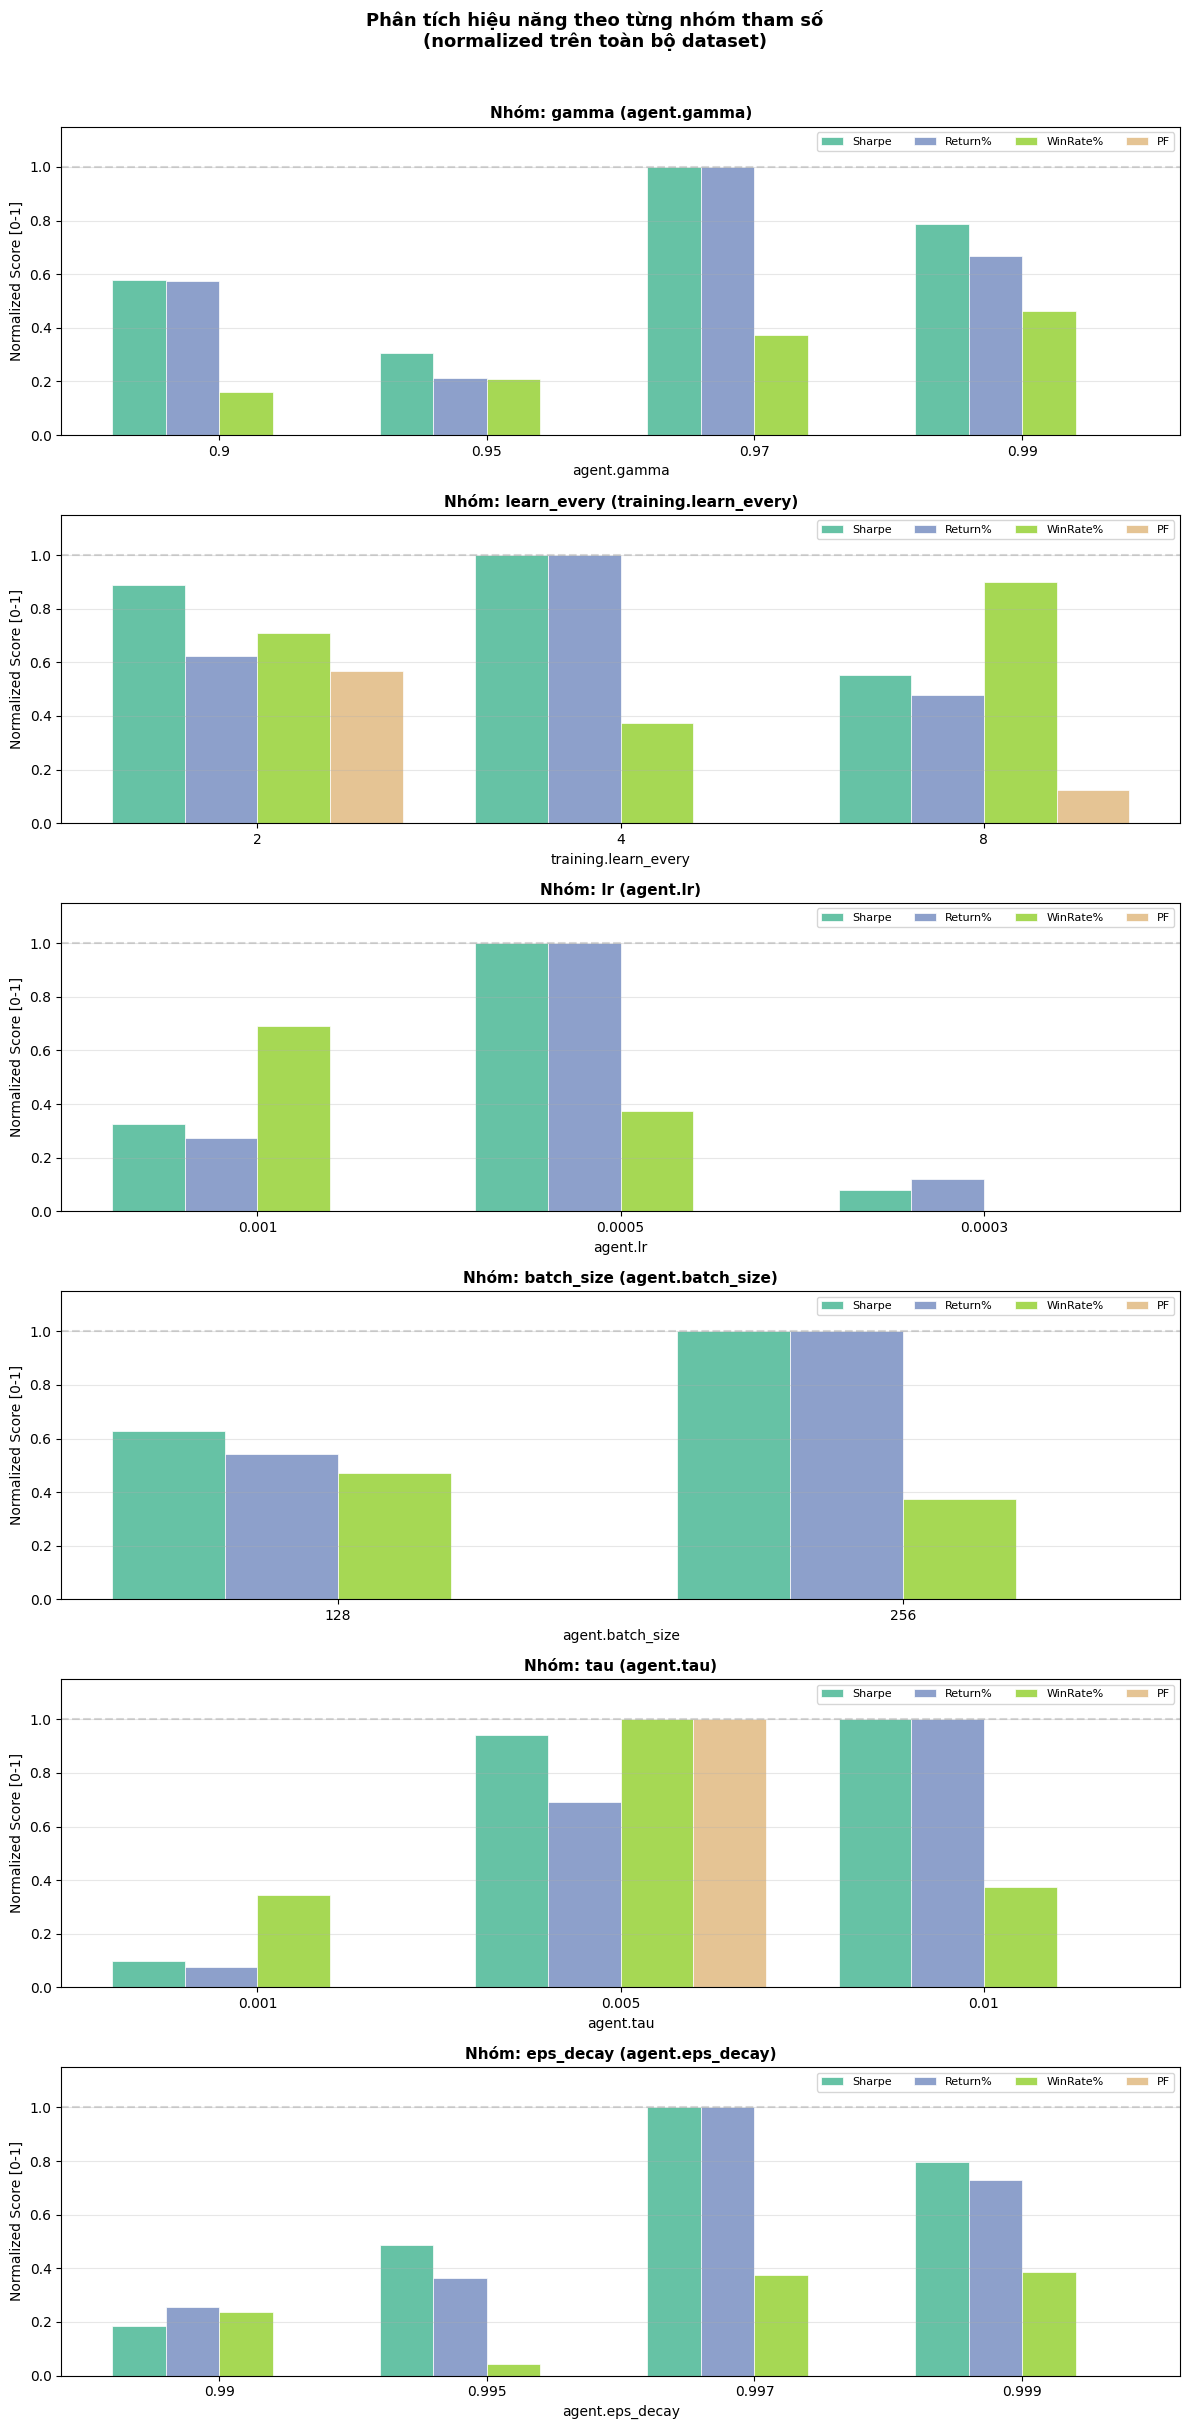

💾 Saved → artifacts/outputs/grouped_bar_by_param.png


In [14]:
# ════════════════════════════════════════════════════════════════
# Grouped bar chart: so sánh hiệu năng theo từng nhóm tham số
# Nhóm dựa trên EXPERIMENTS trong main.ipynb
# ════════════════════════════════════════════════════════════════

# Define param groups (bám theo main.ipynb EXPERIMENTS)
PARAM_GROUPS = {
    "gamma": {"key": "agent.gamma", "values": [0.90, 0.95, 0.97, 0.99]},
    "learn_every": {"key": "training.learn_every", "values": [2, 4, 8]},
    "lr": {"key": "agent.lr", "values": [0.001, 0.0005, 0.0003]},
    "batch_size": {"key": "agent.batch_size", "values": [128, 256]},
    "tau": {"key": "agent.tau", "values": [0.001, 0.005, 0.01]},
    "eps_decay": {"key": "agent.eps_decay", "values": [0.990, 0.995, 0.997, 0.999]},
}

METRICS = ["Sharpe", "Return%", "WinRate%", "PF"]

def get_param_value_from_run(run_data, param_key):
    """Extract param value from run data."""
    parts = param_key.split(".")
    try:
        return run_data["parameters"][parts[0]][parts[1]]
    except (KeyError, TypeError):
        return None

# Build lookup: run_id -> run_data
run_lookup = {r["run_id"]: r for r in all_runs}

# For each param group, collect metrics per value
n_groups = len(PARAM_GROUPS)
fig, axes = plt.subplots(n_groups, 1, figsize=(12, 4 * n_groups))
if n_groups == 1:
    axes = [axes]

bar_colors = plt.cm.Set2(np.linspace(0, 0.8, len(METRICS)))

for ax_idx, (group_name, group_info) in enumerate(PARAM_GROUPS.items()):
    ax = axes[ax_idx]
    param_key = group_info["key"]
    expected_values = group_info["values"]

    # Collect best metric per param value from df_merged
    group_data = []  # list of {"label": ..., metrics...}
    for val in expected_values:
        # Find matching runs in df_merged
        matching = []
        for _, row in df_merged.iterrows():
            run_id = row["run_id"]
            if run_id not in run_lookup:
                continue
            run_val = get_param_value_from_run(run_lookup[run_id], param_key)
            if run_val is not None and abs(float(run_val) - float(val)) < 1e-9:
                matching.append(row)
        if matching:
            # Take the one with best Sharpe
            best_match = max(matching, key=lambda r: r["Sharpe"])
            group_data.append({
                "label": str(val),
                **{m: best_match[m] for m in METRICS},
            })
        else:
            group_data.append({"label": str(val), **{m: 0 for m in METRICS}})

    if not group_data:
        ax.set_visible(False)
        continue

    # Normalize metrics to [0, 1] across ALL configs (not just this group)
    norm_data = []
    for entry in group_data:
        normed = {"label": entry["label"]}
        for m in METRICS:
            col_min = df_merged[m].min()
            col_max = df_merged[m].max()
            if col_max != col_min:
                normed[m] = (entry[m] - col_min) / (col_max - col_min)
            else:
                normed[m] = 0.5
        norm_data.append(normed)

    # Plot grouped bars
    labels = [d["label"] for d in norm_data]
    x = np.arange(len(labels))
    width = 0.8 / len(METRICS)

    for m_idx, metric in enumerate(METRICS):
        values = [d[metric] for d in norm_data]
        offset = (m_idx - len(METRICS) / 2 + 0.5) * width
        bars = ax.bar(x + offset, values, width, label=metric,
                      color=bar_colors[m_idx], edgecolor="white", linewidth=0.5)

    ax.set_xlabel(f"{param_key}")
    ax.set_ylabel("Normalized Score [0-1]")
    ax.set_title(f"Nhóm: {group_name} ({param_key})", fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.15)
    ax.legend(loc="upper right", fontsize=8, ncol=len(METRICS))
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)

plt.suptitle("Phân tích hiệu năng theo từng nhóm tham số\n(normalized trên toàn bộ dataset)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("artifacts/outputs/grouped_bar_by_param.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → artifacts/outputs/grouped_bar_by_param.png")

## 3. Top N Training Curves

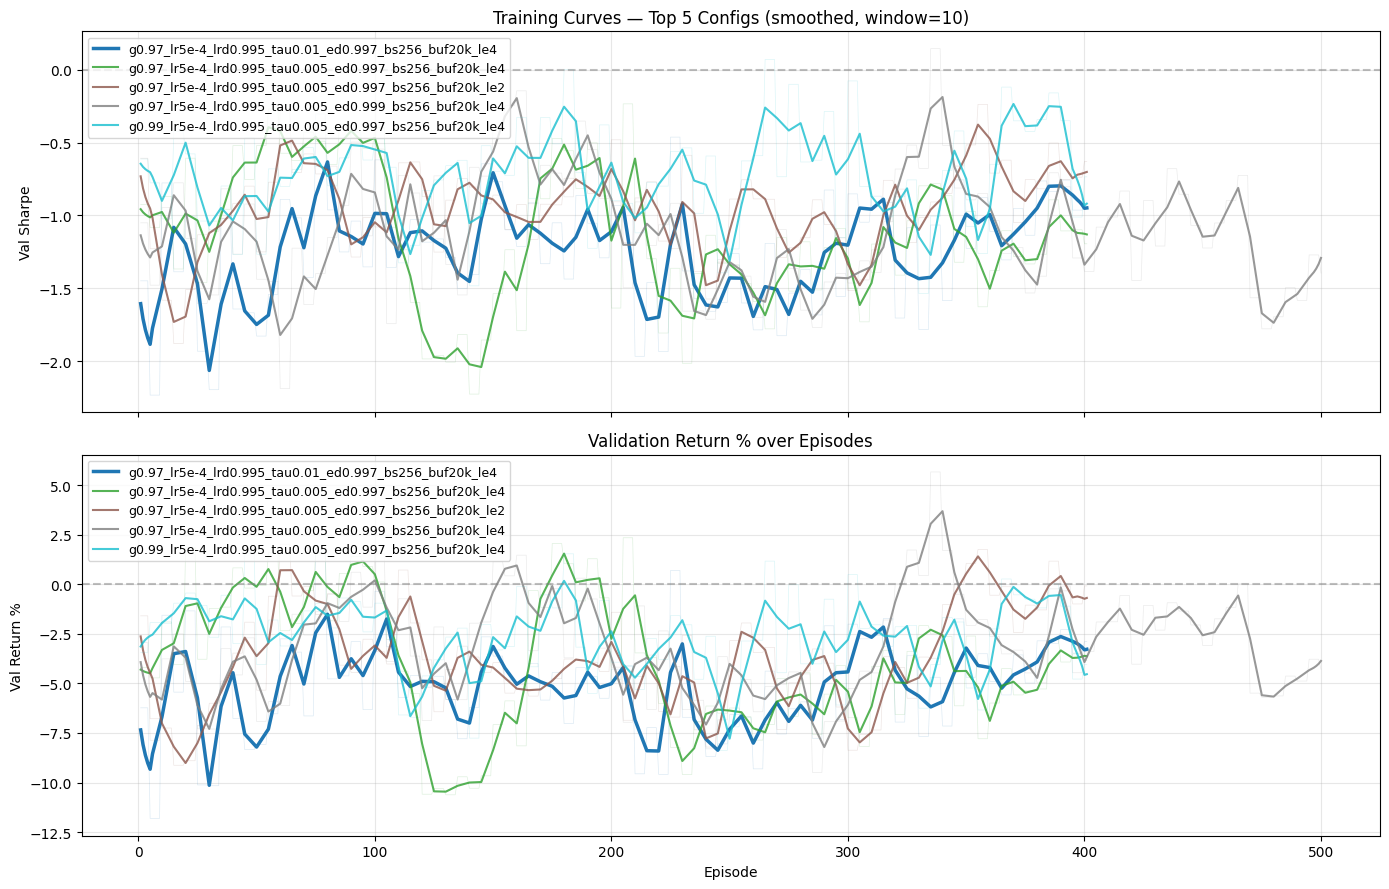

💾 Saved → artifacts/outputs/training_curves_top_n.png


In [15]:
# ════════════════════════════════════════════════════════════════
# Training curves: Top N only + moving average smoothing
# Much cleaner than overlaying all 10+ runs
# ════════════════════════════════════════════════════════════════
TOP_N = 5
SMOOTH_WINDOW = 10  # Moving average window

top_df = df_merged.head(TOP_N)

def smooth(values, window):
    """Simple moving average, handles NaN."""
    arr = pd.Series(values)
    return arr.rolling(window, min_periods=1, center=True).mean().tolist()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
colors_tc = plt.cm.tab10(np.linspace(0, 1, TOP_N))

top_run_ids = top_df["run_id"].tolist()

for i, run_id in enumerate(top_run_ids):
    tlog_path = OUTPUTS_DIR / run_id / "training_log.json"
    if not tlog_path.exists():
        continue
    with open(tlog_path, encoding="utf-8") as f:
        tlog = json.load(f)

    episodes = [e["episode"] for e in tlog]
    val_sharpe = [e.get("val_sharpe", np.nan) for e in tlog]
    val_return = [e.get("val_return", np.nan) for e in tlog]

    exp_name = top_df.iloc[i]["Experiment"]
    lw = 2.5 if i == 0 else 1.5
    alpha = 1.0 if i == 0 else 0.8
    color = colors_tc[i]

    # Raw (faint) + smoothed (bold)
    axes[0].plot(episodes, val_sharpe, color=color, alpha=0.15, linewidth=0.5)
    axes[0].plot(episodes, smooth(val_sharpe, SMOOTH_WINDOW),
                color=color, linewidth=lw, alpha=alpha, label=exp_name)

    axes[1].plot(episodes, val_return, color=color, alpha=0.15, linewidth=0.5)
    axes[1].plot(episodes, smooth(val_return, SMOOTH_WINDOW),
                color=color, linewidth=lw, alpha=alpha, label=exp_name)

axes[0].set_ylabel("Val Sharpe")
axes[0].set_title(f"Training Curves — Top {TOP_N} Configs (smoothed, window={SMOOTH_WINDOW})")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

axes[1].set_ylabel("Val Return %")
axes[1].set_xlabel("Episode")
axes[1].set_title("Validation Return % over Episodes")
axes[1].legend(loc="upper left", fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("artifacts/outputs/training_curves_top_n.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Saved → artifacts/outputs/training_curves_top_n.png")